# Gas Turbine CO and NOx Emissions Modeling

This notebook turns an earlier assignment-style analysis into a reproducible machine learning project. The goal is to predict gas turbine emissions from operating and ambient measurements, compare several regression approaches, and document the tradeoffs in a way that would be clear to a portfolio reviewer.

## 1. Introduction

Gas turbines are instrumented systems: temperature, pressure, humidity, and turbine operating variables are all measured continuously. This project uses those measurements to model two emissions outputs:

- `CO`: carbon monoxide concentration
- `NOX`: nitrogen oxides concentration, written as NOx in narrative text

The primary task is supervised regression. A small classification experiment appears near the end, but it is intentionally labeled as exploratory because the threshold used there is data-derived, not a regulatory standard.

## 2. Dataset Source

The data comes from the UCI Machine Learning Repository:

- Dataset: Gas Turbine CO and NOx Emission Data Set
- UCI dataset id: `551`
- DOI: `10.24432/C5WC95`
- Source page: https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set

The cleaned notebook uses the project loader in `src/emissions_ml/data.py`, which fetches the dataset through `ucimlrepo` and normalizes the returned table into features and targets. If network access is unavailable, place an equivalent raw CSV at `data/raw/gas_turbine_emissions.csv`; raw data files are intentionally ignored by Git.

## 3. Data Loading

The loader returns three tables:

- `features`: predictor columns only
- `targets`: `CO` and `NOX`
- `frame`: the joined modeling table

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from emissions_ml.data import TARGET_COLUMNS, load_emissions_data
from emissions_ml.validation import expanding_window_folds, pre_holdout_years

RANDOM_STATE = 42
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

In [2]:
LOCAL_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "gas_turbine_emissions.csv"

try:
    emissions = load_emissions_data()
    data_source = "UCI Machine Learning Repository via ucimlrepo"
except Exception as exc:
    if LOCAL_DATA_PATH.exists():
        emissions = load_emissions_data(local_path=LOCAL_DATA_PATH)
        data_source = f"Local fallback file: {LOCAL_DATA_PATH}"
    else:
        raise RuntimeError(
            "Could not fetch UCI dataset id 551 and no local fallback file was found. "
            f"Place an equivalent raw CSV at {LOCAL_DATA_PATH} if running offline."
        ) from exc

frame = emissions.frame.copy()
features = emissions.features.copy()
targets = emissions.targets.copy()

print(data_source)
print(f"Rows: {frame.shape[0]:,}")
print(f"Columns: {frame.shape[1]:,}")
frame.head()

UCI Machine Learning Repository via ucimlrepo
Rows: 36,733
Columns: 12


,year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


## 4. Data Quality Checks

Before modeling, check shape, data types, missingness, duplicates, target availability, and the year coverage. The `year` column is useful for validation design, but it is not treated as an operating sensor in the feature matrix.

In [3]:
quality_summary = pd.DataFrame({
    "dtype": frame.dtypes.astype(str),
    "missing_count": frame.isna().sum(),
    "missing_rate": frame.isna().mean(),
    "unique_values": frame.nunique(),
})

print(f"Duplicate rows: {frame.duplicated().sum():,}")
print(f"Target columns: {list(TARGET_COLUMNS)}")
print(f"Year range: {int(frame['year'].min())} to {int(frame['year'].max())}")
quality_summary

Duplicate rows: 7
Target columns: ['CO', 'NOX']
Year range: 2011 to 2015


,dtype,missing_count,missing_rate,unique_values
year,int64,0,0.0,5
AT,float64,0,0.0,22523
AP,float64,0,0.0,791
AH,float64,0,0.0,25708
AFDP,float64,0,0.0,20495
GTEP,float64,0,0.0,12967
TIT,float64,0,0.0,799
TAT,float64,0,0.0,2769
TEY,float64,0,0.0,6236
CDP,float64,0,0.0,4447


In [4]:
frame.describe().T

,count,mean,std,min,25%,50%,75%,max
year,36733.0,2012.985735,1.418965,2011.000000,2012.0000,2013.0000,2014.0000,2015.0000
AT,36733.0,17.712726,7.447451,-6.234800,11.7810,17.8010,23.6650,37.1030
AP,36733.0,1013.070165,6.463346,985.850000,1008.8000,1012.6000,1017.0000,1036.6000
AH,36733.0,77.867015,14.461355,24.085000,68.1880,80.4700,89.3760,100.2000
AFDP,36733.0,3.925518,0.773936,2.087400,3.3556,3.9377,4.3769,7.6106
GTEP,36733.0,25.563801,4.195957,17.698000,23.1290,25.1040,29.0610,40.7160
TIT,36733.0,1081.428084,17.536373,1000.800000,1071.8000,1085.9000,1097.0000,1100.9000
TAT,36733.0,546.158517,6.842360,511.040000,544.7200,549.8800,550.0400,550.6100
TEY,36733.0,133.506404,15.618634,100.020000,124.4500,133.7300,144.0800,179.5000
CDP,36733.0,12.060525,1.088795,9.851800,11.4350,11.9650,12.8550,15.1590


## 5. Exploratory Data Analysis

The exploratory pass focuses on target distributions and correlation structure. These plots are saved to `images/` so the repository can reuse them in the README or project writeup.

Saved /Users/michaelowen/projects/emissions-ml/images/correlation_heatmap.png


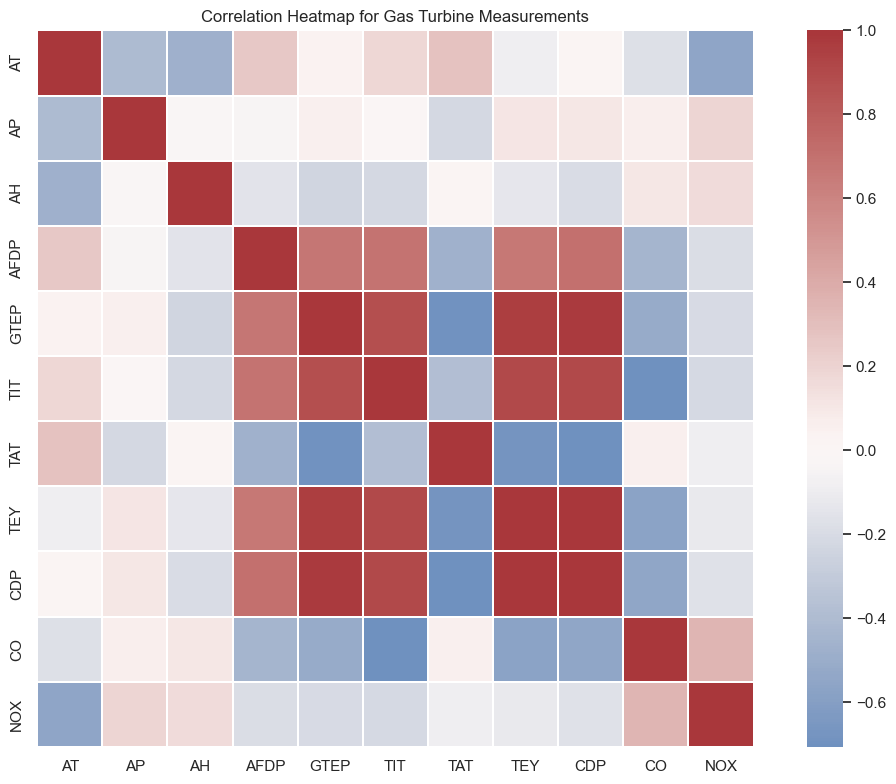

In [5]:
def save_current_figure(filename):
    path = IMAGE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path}")

plt.figure(figsize=(11, 8))
corr = frame.drop(columns=["year"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0, square=True, linewidths=0.25)
plt.title("Correlation Heatmap for Gas Turbine Measurements")
save_current_figure("correlation_heatmap.png")
plt.show()

Saved /Users/michaelowen/projects/emissions-ml/images/co_distribution.png


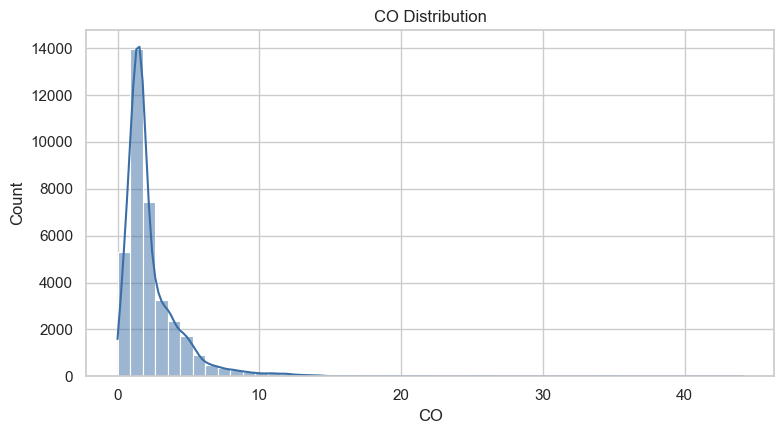

In [6]:
plt.figure(figsize=(8, 4.5))
sns.histplot(frame["CO"], bins=50, kde=True, color="#3a6ea5")
plt.title("CO Distribution")
plt.xlabel("CO")
plt.ylabel("Count")
save_current_figure("co_distribution.png")
plt.show()

Saved /Users/michaelowen/projects/emissions-ml/images/nox_distribution.png

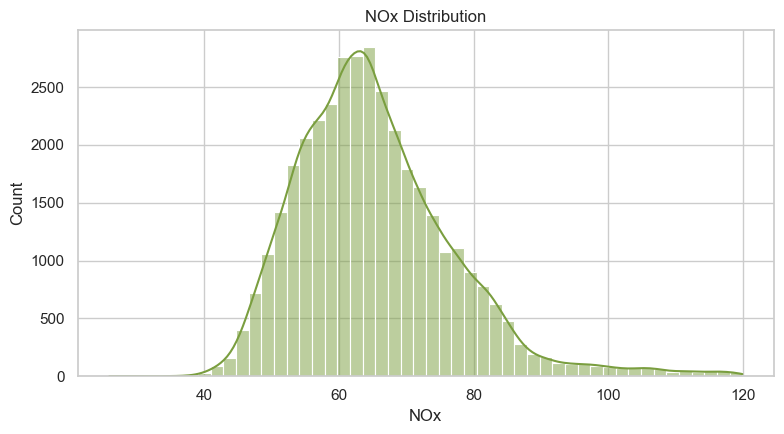

In [7]:
plt.figure(figsize=(8, 4.5))
sns.histplot(frame["NOX"], bins=50, kde=True, color="#7a9e3f")
plt.title("NOx Distribution")
plt.xlabel("NOx")
plt.ylabel("Count")
save_current_figure("nox_distribution.png")
plt.show()

In [8]:
year_target_summary = frame.groupby("year")[list(TARGET_COLUMNS)].agg(["mean", "median", "std", "count"])
year_target_summary.rename(columns={"NOX": "NOx"}, level=0)

CO                                NOx                          
          mean  median       std count       mean   median        std count
year                                                                       
2011  1.572486  1.1557  1.845442  7411  67.575392  65.5420  10.683331  7411
2012  2.361133  1.6363  2.474116  7628  68.788965  67.2465  10.224937  7628
2013  2.723031  1.7827  2.363913  7152  70.007899  68.6510  12.048249  7152
2014  2.081103  1.6553  2.006939  7158  60.066886  59.2785   9.971729  7158
2015  3.129986  2.5334  2.234962  7384  59.890509  56.8385  11.132464  7384

## 6. Feature and Target Definition

The project models `CO` and `NOX` together as a multi-output regression problem. The `year` column is retained for chronological validation design, then removed from the predictors so the models learn from physical and operating measurements rather than collection-year labels.

In [9]:
target_columns = list(TARGET_COLUMNS)
display_target_columns = {"CO": "CO", "NOX": "NOx"}
feature_columns = [column for column in frame.columns if column not in target_columns + ["year"]]

X = frame[feature_columns]
y = frame[target_columns]
year = frame["year"].astype(int)

holdout_year = 2015
rolling_folds = expanding_window_folds(
    start_year=2011,
    validation_years=(2012, 2013, 2014),
    holdout_year=holdout_year,
)
development_years = pre_holdout_years(start_year=2011, holdout_year=holdout_year)

development_mask = year.isin(development_years)
holdout_mask = year == holdout_year

X_development = X.loc[development_mask].copy()
y_development = y.loc[development_mask].copy()
X_holdout = X.loc[holdout_mask].copy()
y_holdout = y.loc[holdout_mask].copy()

fold_overview_rows = []
for fold in rolling_folds:
    fold_train_mask = year.isin(fold.training_years)
    fold_validation_mask = year == fold.validation_year
    training_year_range = (
        str(fold.training_years[0])
        if len(fold.training_years) == 1
        else f"{min(fold.training_years)}-{max(fold.training_years)}"
    )
    fold_overview_rows.append({
        "training_year_range": training_year_range,
        "training_years": ", ".join(str(value) for value in fold.training_years),
        "validation_year": fold.validation_year,
        "available_training_rows": int(fold_train_mask.sum()),
        "validation_rows": int(fold_validation_mask.sum()),
    })

rolling_fold_overview = pd.DataFrame(fold_overview_rows)

print(f"Feature columns ({len(feature_columns)}): {feature_columns}")
print(f"Rolling-origin folds: {len(rolling_folds)}")
print(f"Development rows for final refit: {X_development.shape[0]:,} ({min(development_years)}-{max(development_years)})")
print(f"Final holdout rows: {X_holdout.shape[0]:,} ({holdout_year})")
rolling_fold_overview

Feature columns (9): ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
Rolling-origin folds: 3
Development rows for final refit: 29,349 (2011-2014)
Final holdout rows: 7,384 (2015)


,training_year_range,training_years,validation_year,available_training_rows,validation_rows
0,2011,2011,2012,7411,7628
1,2011-2012,"2011, 2012",2013,15039,7152
2,2011-2013,"2011, 2012, 2013",2014,22191,7158


## 7. Modeling Strategy

Three regression families are compared:

- Ridge regression with `StandardScaler` as a stable linear baseline
- Random forest regression as a tree-based nonlinear model
- Support vector regression with `StandardScaler`, wrapped for multi-output prediction

Model selection now uses expanding-window rolling-origin validation instead of a single 2014 validation year. The folds train on 2011 and validate on 2012, then train on 2011-2012 and validate on 2013, then train on 2011-2013 and validate on 2014. This is more reliable than selecting on 2014 alone because it shows whether a model is stable across multiple future years rather than just one favorable or unfavorable period.

The model never trains on future years within a fold: every validation year is strictly later than the fold's training years. The 2015 data remains an untouched final holdout during model comparison and is used only once after the best model has been selected and refit on all pre-holdout data from 2011-2014. Year-to-year variation in validation metrics is treated as useful evidence of distribution shift. Because `CO` and `NOX` have different numerical scales, model selection uses normalized RMSE (`RMSE / validation-fold target standard deviation`) only to compare models fairly across targets; raw target-level R2, RMSE, and MAE are still reported for interpretation.

All preprocessing is inside scikit-learn pipelines, so scalers are fit only on each fold's training data.

In [10]:
SVR_MAX_TRAIN_ROWS = 5000


def format_year_range(years):
    years = tuple(years)
    if len(years) == 1:
        return str(years[0])
    return f"{min(years)}-{max(years)}"


def regression_metrics(
    model_name,
    y_true,
    y_pred,
    *,
    training_years,
    validation_year,
    training_rows,
    validation_rows,
    available_training_rows=None,
):
    rows = []
    for target in y_true.columns:
        rmse = mean_squared_error(y_true[target], y_pred[target]) ** 0.5
        target_std = y_true[target].std(ddof=0)
        normalized_rmse = rmse / target_std if target_std > 0 else np.nan
        rows.append({
            "model": model_name,
            "target": target,
            "training_year_range": format_year_range(training_years),
            "training_years": ", ".join(str(value) for value in training_years),
            "validation_year": validation_year,
            "available_training_rows": available_training_rows if available_training_rows is not None else training_rows,
            "training_rows": training_rows,
            "validation_rows": validation_rows,
            "r2": r2_score(y_true[target], y_pred[target]),
            "rmse": rmse,
            "mae": mean_absolute_error(y_true[target], y_pred[target]),
            "normalized_rmse": normalized_rmse,
        })
    return pd.DataFrame(rows)


def _predict_ridge_pipeline(model, X_values):
    transformed = X_values
    for _, step in model.steps[:-1]:
        transformed = step.transform(transformed)
    ridge = model.named_steps["model"]
    return np.dot(transformed, ridge.coef_.T) + ridge.intercept_


def predict_dataframe(model, X_values, columns):
    if isinstance(model, Pipeline) and isinstance(model.named_steps.get("model"), Ridge):
        predictions = _predict_ridge_pipeline(model, X_values)
    else:
        predictions = model.predict(X_values)
    return pd.DataFrame(predictions, columns=columns, index=X_values.index)


def training_data_for_model(model_name, X_train_values, y_train_values):
    if model_name != "RBF SVR":
        return X_train_values, y_train_values

    sample_rows = min(SVR_MAX_TRAIN_ROWS, len(X_train_values))
    sample_index = X_train_values.sample(n=sample_rows, random_state=RANDOM_STATE).index
    return X_train_values.loc[sample_index], y_train_values.loc[sample_index]


def fit_and_score(name, estimator, X_train_values, y_train_values, X_eval, y_eval, fold):
    X_fit, y_fit = training_data_for_model(name, X_train_values, y_train_values)
    model = clone(estimator)
    model.fit(X_fit, y_fit)
    predictions = predict_dataframe(model, X_eval, y_eval.columns)
    metrics = regression_metrics(
        name,
        y_eval,
        predictions,
        training_years=fold.training_years,
        validation_year=fold.validation_year,
        training_rows=len(X_fit),
        validation_rows=len(X_eval),
        available_training_rows=len(X_train_values),
    )
    return model, predictions, metrics

## 8. Baseline Regression Model

Ridge regression replaces plain linear regression as the baseline. Gas turbine sensor variables are often correlated, and Ridge regularization gives the linear benchmark more numerical stability while keeping the model simple and interpretable.

In [11]:
ridge_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, solver="lsqr")),
])

ridge_pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(solver='lsqr'))])

## 9. Tree-Based Regression Model

The random forest captures nonlinear relationships and feature interactions without scaling. It can also model both targets directly.

In [12]:
forest_model_spec = RandomForestRegressor(
    n_estimators=150,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

forest_model_spec

RandomForestRegressor(min_samples_leaf=2, n_estimators=150, n_jobs=-1,
                      random_state=42)

## 10. Support Vector Regression Model

Kernel SVR can be effective on nonlinear regression problems, but it scales poorly with row count. To keep this notebook practical and reproducible, each rolling-origin fold trains the RBF SVR on a deterministic sample of at most 5,000 rows from that fold's historical training data only. The same cap is applied again if RBF SVR is selected for the final 2011-2014 refit.

In [13]:
svr_pipeline = MultiOutputRegressor(
    Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")),
    ])
)

svr_pipeline

MultiOutputRegressor(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                               ('model', SVR(C=10.0))]))

## 11. Model Comparison

The comparison table below keeps every target-year result visible. Model selection uses the mean normalized RMSE across all validation years and both targets, while the raw target-level R2, RMSE, and MAE remain available for interpretation. Lower RMSE, MAE, and normalized RMSE are better; higher R2 is better.

In [14]:
model_specs = {
    "Ridge Regression": ridge_pipeline,
    "Random Forest": forest_model_spec,
    "RBF SVR": svr_pipeline,
}

validation_metric_frames = []
validation_predictions_by_model_fold = {}

for fold in rolling_folds:
    fold_train_mask = year.isin(fold.training_years)
    fold_validation_mask = year == fold.validation_year

    X_fold_train = X.loc[fold_train_mask].copy()
    y_fold_train = y.loc[fold_train_mask].copy()
    X_fold_validation = X.loc[fold_validation_mask].copy()
    y_fold_validation = y.loc[fold_validation_mask].copy()

    for model_name, estimator in model_specs.items():
        fitted_model, predictions, metrics = fit_and_score(
            model_name,
            estimator,
            X_fold_train,
            y_fold_train,
            X_fold_validation,
            y_fold_validation,
            fold,
        )
        validation_metric_frames.append(metrics)
        validation_predictions_by_model_fold[(model_name, fold.validation_year)] = predictions

validation_metrics = pd.concat(validation_metric_frames, ignore_index=True)

validation_results_display = (
    validation_metrics
    .assign(target=lambda df: df["target"].replace(display_target_columns))
    .loc[:, [
        "model",
        "target",
        "training_year_range",
        "validation_year",
        "available_training_rows",
        "training_rows",
        "validation_rows",
        "r2",
        "rmse",
        "mae",
        "normalized_rmse",
    ]]
    .sort_values(["validation_year", "model", "target"])
)

annual_model_results = (
    validation_metrics
    .groupby(["model", "validation_year"], as_index=False)
    .agg(
        normalized_rmse=("normalized_rmse", "mean"),
        r2=("r2", "mean"),
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
    )
    .sort_values(["validation_year", "normalized_rmse"])
)

print("Target-level rolling-origin validation results")
display(validation_results_display)
print("Annual model averages across CO and NOx")
display(annual_model_results)

Target-level rolling-origin validation results


,model,target,training_year_range,validation_year,available_training_rows,training_rows,validation_rows,r2,rmse,mae,normalized_rmse
4,RBF SVR,CO,2011,2012,7411,5000,7628,0.482895,1.779022,0.890155,0.719100
5,RBF SVR,NOx,2011,2012,7411,5000,7628,0.723644,5.374853,3.795492,0.525696
2,Random Forest,CO,2011,2012,7411,7411,7628,0.434269,1.860787,1.005151,0.752151
3,Random Forest,NOx,2011,2012,7411,7411,7628,0.715339,5.455017,3.959140,0.533536
0,Ridge Regression,CO,2011,2012,7411,7411,7628,0.414249,1.893425,1.011934,0.765344
1,Ridge Regression,NOx,2011,2012,7411,7411,7628,0.447099,7.602491,5.790445,0.743573
10,RBF SVR,CO,2011-2012,2013,15039,5000,7152,0.640000,1.418248,0.898577,0.600000
11,RBF SVR,NOx,2011-2012,2013,15039,5000,7152,0.603463,7.586395,5.511343,0.629712
8,Random Forest,CO,2011-2012,2013,15039,15039,7152,0.651739,1.394935,0.824769,0.590137
9,Random Forest,NOx,2011-2012,2013,15039,15039,7152,0.595619,7.661062,5.695140,0.635910


Annual model averages across CO and NOx


,model,validation_year,normalized_rmse,r2,rmse,mae
0,RBF SVR,2012,0.622398,0.603269,3.576937,2.342823
3,Random Forest,2012,0.642843,0.574804,3.657902,2.482146
6,Ridge Regression,2012,0.754458,0.430674,4.747958,3.401189
4,Random Forest,2013,0.613023,0.623679,4.527998,3.259954
1,RBF SVR,2013,0.614856,0.621732,4.502322,3.204960
7,Ridge Regression,2013,0.762443,0.404833,6.063617,4.299695
8,Ridge Regression,2014,0.813647,0.335417,5.074397,3.721732
5,Random Forest,2014,0.909333,0.148939,6.065063,4.970481
2,RBF SVR,2014,0.995367,-0.001110,6.366361,5.373627


In [15]:
model_selection_summary = (
    annual_model_results
    .groupby("model", as_index=False)
    .agg(
        mean_normalized_rmse=("normalized_rmse", "mean"),
        std_normalized_rmse=("normalized_rmse", "std"),
        mean_r2=("r2", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
    )
    .sort_values("mean_normalized_rmse")
)

target_level_summary = (
    validation_metrics
    .groupby(["model", "target"], as_index=False)
    .agg(
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        normalized_rmse_mean=("normalized_rmse", "mean"),
        normalized_rmse_std=("normalized_rmse", "std"),
    )
    .sort_values(["target", "normalized_rmse_mean"])
)

best_model_name = model_selection_summary.iloc[0]["model"]
best_model_selection_row = model_selection_summary.iloc[0]

target_level_summary_display = target_level_summary.assign(
    target=lambda df: df["target"].replace(display_target_columns)
)

print("Model selection summary from annual model averages")
display(model_selection_summary)
print("Target-level summary across rolling-origin folds")
display(target_level_summary_display)
print(
    "Best model by mean normalized RMSE across rolling-origin folds: "
    f"{best_model_name} ({best_model_selection_row['mean_normalized_rmse']:.3f})"
)

Model selection summary from annual model averages


,model,mean_normalized_rmse,std_normalized_rmse,mean_r2,mean_rmse,mean_mae
1,Random Forest,0.721733,0.163149,0.449141,4.750321,3.570860
0,RBF SVR,0.744207,0.217544,0.407964,4.815207,3.640470
2,Ridge Regression,0.776850,0.032117,0.390308,5.295324,3.807538


Target-level summary across rolling-origin folds


,model,target,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,normalized_rmse_mean,normalized_rmse_std
2,Random Forest,CO,0.505905,0.126302,1.589517,0.242209,0.872488,0.116388,0.698713,0.094034
4,Ridge Regression,CO,0.472100,0.097165,1.649584,0.211203,0.947290,0.056400,0.724383,0.068960
0,RBF SVR,CO,0.441449,0.222192,1.663525,0.212536,1.010940,0.201957,0.737572,0.147676
3,Random Forest,NOx,0.392376,0.459622,7.911125,2.590209,6.269233,2.644300,0.744753,0.281867
1,RBF SVR,NOx,0.374478,0.504286,7.966889,2.801728,6.270000,2.928490,0.750842,0.304361
5,Ridge Regression,NOx,0.308516,0.120811,8.941064,1.526279,6.667786,0.950511,0.829317,0.074679


Best model by mean normalized RMSE across rolling-origin folds: Random Forest (0.722)


In [16]:
best_model = clone(model_specs[best_model_name])
X_final_fit, y_final_fit = training_data_for_model(best_model_name, X_development, y_development)
best_model.fit(X_final_fit, y_final_fit)

holdout_predictions = predict_dataframe(best_model, X_holdout, y_holdout.columns)
holdout_metrics = regression_metrics(
    best_model_name,
    y_holdout,
    holdout_predictions,
    training_years=development_years,
    validation_year=holdout_year,
    training_rows=len(X_final_fit),
    validation_rows=len(X_holdout),
    available_training_rows=len(X_development),
)

holdout_metrics_display = (
    holdout_metrics
    .assign(target=lambda df: df["target"].replace(display_target_columns))
    .loc[:, ["target", "r2", "rmse", "mae"]]
)

print(
    f"Refit {best_model_name} on {format_year_range(development_years)} development data "
    f"({len(X_final_fit):,} training rows used from {len(X_development):,} available)."
)
print(f"Evaluated once on the untouched {holdout_year} final holdout.")
holdout_metrics_display

Refit Random Forest on 2011-2014 development data (29,349 training rows used from 29,349 available).
Evaluated once on the untouched 2015 final holdout.


,target,r2,rmse,mae
0,CO,0.471854,1.624119,1.036697
1,NOx,-0.021192,11.249042,9.243786


Saved /Users/michaelowen/projects/emissions-ml/images/model_comparison.png


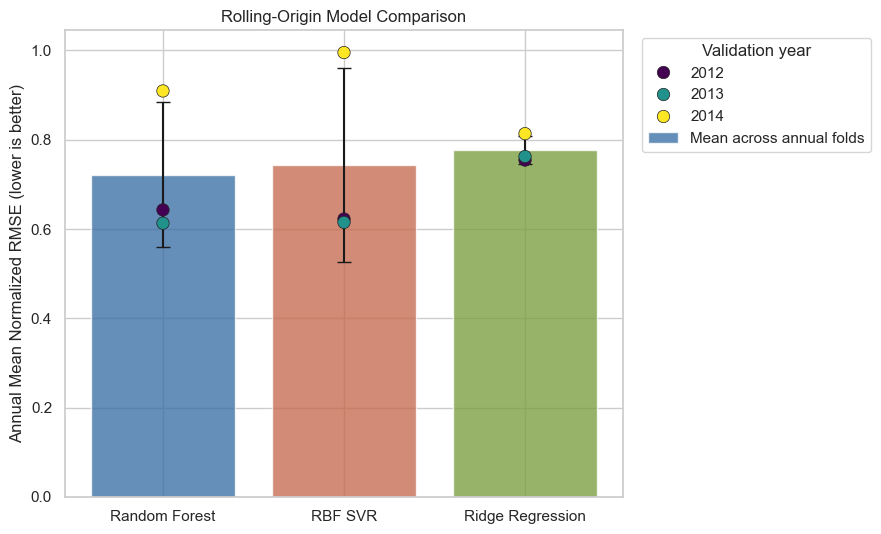

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_summary = model_selection_summary.set_index("model").loc[model_selection_summary["model"]]
x_positions = np.arange(len(plot_summary))

ax.bar(
    x_positions,
    plot_summary["mean_normalized_rmse"],
    yerr=plot_summary["std_normalized_rmse"],
    capsize=5,
    color=["#3a6ea5", "#c56b4f", "#7a9e3f"][:len(plot_summary)],
    alpha=0.78,
    label="Mean across annual folds",
)

annual_points = annual_model_results.copy()
model_to_x = {model: position for position, model in enumerate(plot_summary.index)}
annual_points["x"] = annual_points["model"].map(model_to_x)
sns.scatterplot(
    data=annual_points,
    x="x",
    y="normalized_rmse",
    hue="validation_year",
    palette="viridis",
    s=80,
    edgecolor="#222222",
    linewidth=0.5,
    ax=ax,
    zorder=3,
)

ax.set_xticks(x_positions)
ax.set_xticklabels(plot_summary.index)
ax.set_title("Rolling-Origin Model Comparison")
ax.set_xlabel("")
ax.set_ylabel("Annual Mean Normalized RMSE (lower is better)")
ax.legend(title="Validation year", bbox_to_anchor=(1.02, 1), loc="upper left")
save_current_figure("model_comparison.png")
plt.show()

Saved /Users/michaelowen/projects/emissions-ml/images/actual_vs_predicted_best_model.png


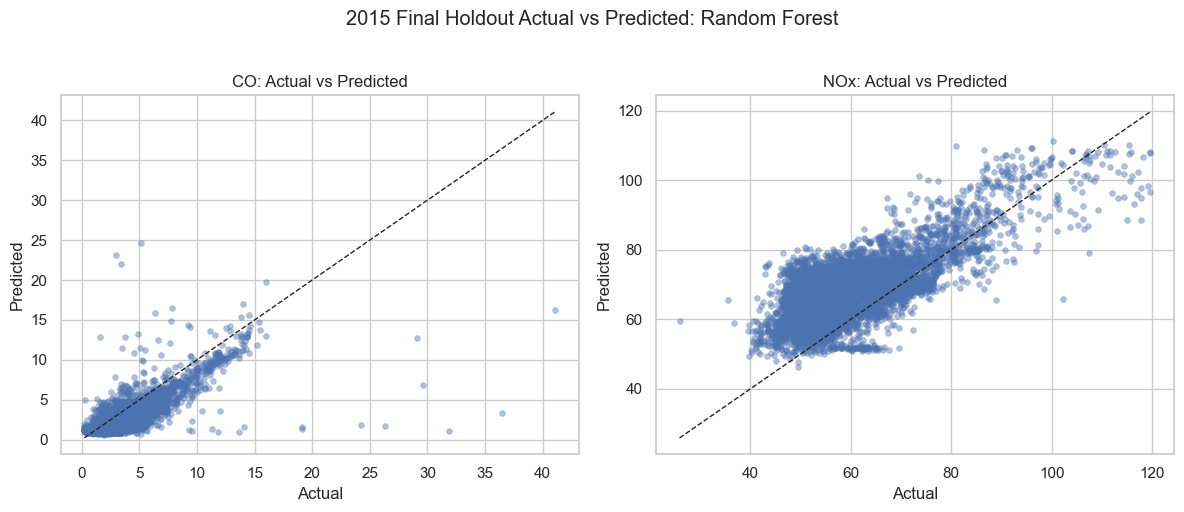


### Interpretation

Rolling-origin validation selected **Random Forest** with mean normalized RMSE of **0.722** across the 2012-2014 validation years and both targets. Its annual mean normalized RMSE ranged from **0.613** to **0.909** (standard deviation **0.163**), which is evidence that the target relationships shift by year rather than staying perfectly stationary.

The selected model was refit only after model selection, using the 2011-2014 development data. The 2015 final holdout remained untouched until this evaluation. On 2015, the model reached CO RMSE **1.624** with R2 **0.472**, and NOx RMSE **11.249** with R2 **-0.021**. The 2015 actual-versus-predicted plots show underprediction of extreme CO values and compression toward the middle for NOx.

Target-level validation results were not identical: CO had the lowest mean normalized RMSE with **Random Forest**, while NOx had the lowest mean normalized RMSE with **Random Forest**. The selected model improved mean normalized RMSE 

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target in zip(axes, target_columns):
    label = display_target_columns.get(target, target)
    sns.scatterplot(x=y_holdout[target], y=holdout_predictions[target], s=18, alpha=0.45, ax=ax, edgecolor=None)
    lower = min(y_holdout[target].min(), holdout_predictions[target].min())
    upper = max(y_holdout[target].max(), holdout_predictions[target].max())
    ax.plot([lower, upper], [lower, upper], color="#222222", linestyle="--", linewidth=1)
    ax.set_title(f"{label}: Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
fig.suptitle(f"2015 Final Holdout Actual vs Predicted: {best_model_name}", y=1.02)
save_current_figure("actual_vs_predicted_best_model.png")
plt.show()

best_annual = annual_model_results.loc[annual_model_results["model"] == best_model_name]
best_annual_min = best_annual["normalized_rmse"].min()
best_annual_max = best_annual["normalized_rmse"].max()
best_annual_std = best_annual["normalized_rmse"].std()

best_by_target = (
    target_level_summary
    .sort_values("normalized_rmse_mean")
    .drop_duplicates("target")
    .set_index("target")
)
co_best = best_by_target.loc["CO", "model"]
nox_best = best_by_target.loc["NOX", "model"]
co_holdout_rmse = holdout_metrics.loc[holdout_metrics["target"] == "CO", "rmse"].iloc[0]
nox_holdout_rmse = holdout_metrics.loc[holdout_metrics["target"] == "NOX", "rmse"].iloc[0]
co_holdout_r2 = holdout_metrics.loc[holdout_metrics["target"] == "CO", "r2"].iloc[0]
nox_holdout_r2 = holdout_metrics.loc[holdout_metrics["target"] == "NOX", "r2"].iloc[0]
baseline_name = "Ridge Regression"
baseline_norm = model_selection_summary.loc[
    model_selection_summary["model"] == baseline_name,
    "mean_normalized_rmse",
].iloc[0]
best_norm = best_model_selection_row["mean_normalized_rmse"]
relative_improvement = (baseline_norm - best_norm) / baseline_norm
runner_up = model_selection_summary.iloc[1]
runner_up_model_name = runner_up["model"]
runner_up_norm = runner_up["mean_normalized_rmse"]
runner_up_gap = runner_up_norm - best_norm
validation_year_count = annual_model_results["validation_year"].nunique()

if best_model_name == baseline_name:
    nonlinear_takeaway = (
        "The nonlinear models did not beat the Ridge baseline on the normalized selection metric, "
        "although target-level results still show where individual models behave differently."
    )
else:
    nonlinear_takeaway = (
        f"The selected model improved mean normalized RMSE by {relative_improvement:.1%} versus "
        f"the Ridge baseline, but the win is modest: its mean normalized RMSE is only "
        f"{runner_up_gap:.3f} lower than {runner_up_model_name}, and the comparison spans "
        f"only {validation_year_count} validation years."
    )

interpretation = f"""
### Interpretation

Rolling-origin validation selected **{best_model_name}** with mean normalized RMSE of **{best_norm:.3f}** across the 2012-2014 validation years and both targets. Its annual mean normalized RMSE ranged from **{best_annual_min:.3f}** to **{best_annual_max:.3f}** (standard deviation **{best_annual_std:.3f}**), which is evidence that the target relationships shift by year rather than staying perfectly stationary.

The selected model was refit only after model selection, using the 2011-2014 development data. The 2015 final holdout remained untouched until this evaluation. On 2015, the model reached CO RMSE **{co_holdout_rmse:.3f}** with R2 **{co_holdout_r2:.3f}**, and NOx RMSE **{nox_holdout_rmse:.3f}** with R2 **{nox_holdout_r2:.3f}**. The 2015 actual-versus-predicted plots show underprediction of extreme CO values and compression toward the middle for NOx.

Target-level validation results were not identical: CO had the lowest mean normalized RMSE with **{co_best}**, while NOx had the lowest mean normalized RMSE with **{nox_best}**. {nonlinear_takeaway} Normalized RMSE is used for fair model selection across differently scaled targets; the raw RMSE and MAE values remain the clearest way to discuss target-specific prediction error.
"""
print(interpretation)

## 12. Optional Classification Experiment

This section is exploratory. It converts `CO` into a binary label using the median `CO` value from the 2011-2014 development period. That threshold is useful for a modeling demonstration, but it is not a compliance threshold and should not be interpreted as a regulatory claim.

A random forest classifier is used here after logistic regression produced numerical warnings in this environment. The classifier avoids scaling and keeps the optional experiment separate from the primary regression workflow.

In [19]:
co_threshold = float(y_development["CO"].median())
y_development_high_co = (y_development["CO"] > co_threshold).astype(int)
y_holdout_high_co = (y_holdout["CO"] > co_threshold).astype(int)

classification_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
classification_model.fit(X_development, y_development_high_co)
holdout_class_predictions = classification_model.predict(X_holdout)

classification_results = pd.DataFrame([
    {
        "evaluation_period": "2015 final holdout",
        "threshold_basis": "2011-2014 development median CO",
        "threshold_value": co_threshold,
        "accuracy": accuracy_score(y_holdout_high_co, holdout_class_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_holdout_high_co, holdout_class_predictions),
    },
])
classification_results

,evaluation_period,threshold_basis,threshold_value,accuracy,balanced_accuracy
0,2015 final holdout,2011-2014 development median CO,1.5619,0.633938,0.754535


## 13. Final Takeaways

This project demonstrates a reproducible regression workflow for modeling gas turbine CO and NOx emissions from operating and ambient sensor measurements. A few lessons stand out:

- Regression metrics tell different stories: R2 is useful for explained variance, while RMSE and MAE keep the discussion grounded in prediction error.
- Expanding-window validation gives a stronger chronological model comparison than selecting from one validation year because it exposes year-to-year stability and drift.
- The fold design never trains on future years, and 2015 remains a final holdout until after model selection.
- Normalized RMSE is useful for fair model selection across CO and NOx, while raw target-level metrics are still needed to interpret practical error.
- Ridge regression is a sensible linear baseline when sensor variables are correlated, but nonlinear models can capture relationships a linear model misses.
- More flexible models can improve validation performance, but they also raise overfitting and runtime concerns.
- Pipelines make preprocessing safer because scaling is learned only from the training data.
- The optional classification framing is useful for experimentation, but any emissions compliance threshold would need to come from a cited regulatory source rather than the dataset itself.